# 02 — GAN music generation

A GAN whose generator maps 1000-dimensional noise to a 100-note sequence. An LSTM discriminator judges real vs. generated sequences. The architecture and training settings are the original project's:

- **Generator:** Dense layers of 256 → 512 → 1024 units, each with LeakyReLU and BatchNorm, then a tanh output.
- **Discriminator:** a 512-unit LSTM, then a bidirectional 512-unit LSTM, then Dense 512 → 256 → sigmoid.
- **Training:** Adam (2e-4, β₁ 0.5), batch size 32, 30,000 iterations.

**Changes from the 2024 notebook** (the original is kept in `notebooks/original_2024/`):

| Change | Why |
|---|---|
| Notes parsed from the Pokémon MIDI files | The original loaded a `data/notes` pickle that isn't in the repo, and unzipped a different dataset (`midi_songs.zip`) |
| `CuDNNLSTM` → `LSTM`; TensorFlow 1 imports removed | Removed in TensorFlow 2 |
| Training step written with `tf.GradientTape` | The old "freeze the discriminator, then compile the combined model" trick is unreliable in Keras 3 |
| Generated values mapped with `n_vocab / 2` instead of the hard-coded 242 | 242 assumed a 484-token vocabulary and crashes with a `KeyError` on this one |
| `create_midi` uses the whole token | The original took `item[0]`, the first *character*, so `'C#4'` became `'C'` |
| Progress printed every 1,000 iterations instead of every iteration | 30,000 output lines can freeze the Colab tab |
| Novelty, diversity and FAD proxy added | This code was in the Colab screenshots (`results/figures/gan/`) but not in this notebook |

**Runtime.** Roughly 20 to 40 minutes on a Colab T4.

**Running on Google Colab.** Upload this notebook, then choose *Runtime → Change runtime type → T4 GPU* and *Runtime → Run all*. The paths cell will ask you to upload `data/pokemon_midis.zip` from the repo. The generated music is saved as `.mid`, rendered to `.wav` and played inline. The last cell downloads every output as one zip. Unzip it into the repo's `results/` folder to keep the outputs.

**Running locally.** Run `pip install -r requirements.txt`, then open this notebook from the repo's `notebooks/` folder. WAV rendering needs [FluidSynth](https://www.fluidsynth.org/) and a General MIDI soundfont. Without them the notebook still saves the `.mid` files.

## 1. Setup

In [ ]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "music21"], check=True)
    # FluidSynth + a General MIDI soundfont render the generated .mid files to playable .wav audio
    subprocess.run("apt-get update -qq && apt-get install -y -qq fluidsynth fluid-soundfont-gm > /dev/null",
                   shell=True, check=True)

In [ ]:
import json
import pickle
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from music21 import converter, instrument, note, chord, stream
from scipy.spatial.distance import euclidean
from sklearn.metrics import mean_squared_error
from IPython.display import Audio, display

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | Keras 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ---- Configuration (original values unless noted) -------------------------
SEQUENCE_LENGTH = 100
LATENT_DIM = 1000
ITERATIONS = 30000          # called "epochs" in the original; each is one batch
BATCH_SIZE = 32
LEARNING_RATE, BETA_1 = 0.0002, 0.5
LOG_EVERY = 1000            # original printed every iteration

N_GEN_SAMPLES = 100         # sequences generated for novelty / diversity / FAD
AUDIO_SEQUENCES = 5         # generated sequences joined into the audio piece (5 x 100 = 500 notes)

np.random.seed(1)           # original seeds
tf.random.set_seed(2)
rng = np.random.default_rng(1)

# ---- Paths: locally, find the repo from notebooks/ or the repo root; on Colab, upload the dataset
def find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "pokemon_midis.zip").exists():
            return p
    return None


REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    if not IN_COLAB:
        raise FileNotFoundError("data/pokemon_midis.zip not found - run this notebook from inside the repo.")
    from google.colab import files
    REPO_ROOT = Path("/content/symphony-of-algorithms")
    (REPO_ROOT / "data").mkdir(parents=True, exist_ok=True)
    print("Select data/pokemon_midis.zip from the repo:")
    uploaded = files.upload()
    (REPO_ROOT / "data" / "pokemon_midis.zip").write_bytes(next(iter(uploaded.values())))

DATA_ZIP = REPO_ROOT / "data" / "pokemon_midis.zip"
MIDI_DIR = REPO_ROOT / "data" / "Pokemon MIDIs"
if not MIDI_DIR.exists():
    with zipfile.ZipFile(DATA_ZIP) as zf:
        zf.extractall(DATA_ZIP.parent)

AUDIO_DIR = REPO_ROOT / "results" / "audio"
WEIGHTS_DIR = REPO_ROOT / "Weights"
for d in (AUDIO_DIR, WEIGHTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"{len(list(MIDI_DIR.glob('*.mid')))} MIDI files in {MIDI_DIR.relative_to(REPO_ROOT)}")

FIG_DIR = REPO_ROOT / "results" / "figures" / "gan_reproduced"
FIG_DIR.mkdir(parents=True, exist_ok=True)

Select data/pokemon_midis.zip from the repo:


Saving pokemon_midis.zip to pokemon_midis.zip
307 MIDI files in data/Pokemon MIDIs


In [ ]:
SOUNDFONT = Path("/usr/share/sounds/sf2/FluidR3_GM.sf2")


def midi_to_wav(midi_path):
    # Render a .mid file to .wav with FluidSynth (installed automatically on Colab)
    if shutil.which("fluidsynth") is None or not SOUNDFONT.exists():
        print("FluidSynth or the soundfont is not installed - skipping WAV rendering (the .mid file is saved).")
        return None
    wav_path = midi_path.with_suffix(".wav")
    subprocess.run(["fluidsynth", "-ni", "-F", str(wav_path), "-r", "44100", str(SOUNDFONT), str(midi_path)],
                   check=True, capture_output=True)
    return wav_path


def save_and_play(midi_path):
    wav_path = midi_to_wav(midi_path)
    print(f"Saved {midi_path.relative_to(REPO_ROOT)}" + (f" and {wav_path.relative_to(REPO_ROOT)}" if wav_path else ""))
    if wav_path:
        display(Audio(str(wav_path)))

# Same definitions as the GAN evaluation in the original project (results/figures/gan/*.png)
def novelty_metric(generated_sequences, real_sequences):
    distances = []
    for gen_seq in generated_sequences:
        gen_seq_flat = gen_seq.flatten()
        real_distances = [euclidean(gen_seq_flat, real_seq.flatten()) for real_seq in real_sequences]
        distances.append(np.mean(real_distances))
    return np.mean(distances)


def nearest_neighbour_novelty(generated_sequences, real_sequences):
    # The definition RESULTS.md describes: distance to the *closest* real sequence
    return np.mean([min(euclidean(g.flatten(), r.flatten()) for r in real_sequences)
                    for g in generated_sequences])


def diversity_metric(sequences):
    n = len(sequences)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(euclidean(sequences[i].flatten(), sequences[j].flatten()))
    return np.mean(distances)


def fad_metric(generated_sequences, real_sequences):
    gen_means = np.mean(generated_sequences, axis=0)
    gen_vars = np.var(generated_sequences, axis=0)
    real_means = np.mean(real_sequences, axis=0)
    real_vars = np.var(real_sequences, axis=0)
    mean_diff = mean_squared_error(gen_means.flatten(), real_means.flatten())
    var_diff = mean_squared_error(gen_vars.flatten(), real_vars.flatten())
    return mean_diff + var_diff


def generation_metrics(generated_sequences, real_sequences):
    return {
        "novelty (mean distance, as in original code)": float(novelty_metric(generated_sequences, real_sequences)),
        "novelty (nearest neighbour, as in RESULTS.md)": float(nearest_neighbour_novelty(generated_sequences, real_sequences)),
        "diversity": float(diversity_metric(generated_sequences)),
        "FAD proxy": float(fad_metric(generated_sequences, real_sequences)),
    }

def create_midi(prediction_output, midi_path):
    # Convert note / chord tokens back to a MIDI file (original logic; every note is now played on piano)
    offset = 0
    output_notes = []
    for pattern in prediction_output:
        if ("." in pattern) or pattern.isdigit():      # pattern is a chord
            chord_notes = []
            for current_note in pattern.split("."):
                new_note = note.Note(int(current_note))
                new_note.storedInstrument = instrument.Piano()
                chord_notes.append(new_note)
            new_chord = chord.Chord(chord_notes)
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:                                          # pattern is a note
            new_note = note.Note(pattern)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)
        offset += 0.5                                  # so that notes do not stack
    midi_stream = stream.Stream(output_notes)
    midi_stream.insert(0, instrument.Piano())
    midi_stream.write("midi", fp=str(midi_path))

def save_summary(model, path):
    lines = []
    model.summary(print_fn=lambda line, *args, **kwargs: lines.append(line))
    path.write_text("\n".join(lines), encoding="utf-8")
    model.summary()

## 2. Read and process the data

In [ ]:
NOTES_CACHE = REPO_ROOT / "data" / "notes"


def get_notes():
    # Parse every MIDI file into note / chord tokens (as in the original); cached in data/notes after the first run
    if NOTES_CACHE.exists():
        with open(NOTES_CACHE, "rb") as f:
            return pickle.load(f)
    notes = []
    midi_files = sorted(MIDI_DIR.glob("*.mid"))
    print(f"Parsing {len(midi_files)} MIDI files with music21 (a few minutes; cached afterwards)...")
    for file in midi_files:
        try:
            midi = converter.parse(file)
        except Exception as e:  # a few fan transcriptions are malformed
            print(f"  skipped {file.name}: {e!r}")
            continue
        try:  # file has instrument parts: use the first part
            notes_to_parse = instrument.partitionByInstrument(midi).parts[0].recurse()
        except Exception:  # file has notes in a flat structure
            notes_to_parse = midi.flatten().notes
        for element in notes_to_parse:
            if isinstance(element, note.Note):
                notes.append(str(element.pitch))
            elif isinstance(element, chord.Chord):
                notes.append(".".join(str(n) for n in element.normalOrder))
    with open(NOTES_CACHE, "wb") as f:
        pickle.dump(notes, f)
    return notes


notes = get_notes()
pitchnames = sorted(set(notes))
n_vocab = len(pitchnames)
note_to_int = {token: i for i, token in enumerate(pitchnames)}
print(f"{len(notes):,} note/chord tokens, vocabulary of {n_vocab}")

Parsing 307 MIDI files with music21 (a few minutes; cached afterwards)...


/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=6, data=b'Pok\xe9mon: Elite Four (Piano)'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pok\xe9mon Gym'>; getting generic Instrument
  warnings.warn(


128,870 note/chord tokens, vocabulary of 627


In [ ]:
def prepare_sequences(notes):
    # 100-note sliding windows, normalised to [-1, 1] to match the generator's tanh output (original logic)
    encoded = np.array([note_to_int[token] for token in notes], dtype=np.int32)
    n_patterns = len(encoded) - SEQUENCE_LENGTH
    window_idx = np.arange(n_patterns)[:, None] + np.arange(SEQUENCE_LENGTH)[None, :]
    int_input = encoded[window_idx]
    return ((int_input - n_vocab / 2) / (n_vocab / 2)).astype(np.float32)[..., None]


X_train = prepare_sequences(notes)
print(f"{len(X_train):,} real sequences of {SEQUENCE_LENGTH} notes, values in [-1, 1]")

128,770 real sequences of 100 notes, values in [-1, 1]


## 3. Model

In [ ]:
def build_discriminator():
    return keras.Sequential([
        keras.Input(shape=(SEQUENCE_LENGTH, 1)),
        layers.LSTM(512, return_sequences=True),
        layers.Bidirectional(layers.LSTM(512)),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminator")


def build_generator():
    return keras.Sequential([
        keras.Input(shape=(LATENT_DIM,)),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(momentum=0.8),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(momentum=0.8),
        layers.Dense(1024),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(momentum=0.8),
        layers.Dense(SEQUENCE_LENGTH, activation="tanh"),
        layers.Reshape((SEQUENCE_LENGTH, 1)),
    ], name="generator")


discriminator = build_discriminator()
generator = build_generator()
save_summary(discriminator, FIG_DIR / "discriminator_model_summary.txt")
save_summary(generator, FIG_DIR / "generator_model_summary.txt")

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 512)       │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1024)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,907,457 (22.54 MB)

 Trainable params: 5,907,457 (22.54 MB)

 Non-trainable params: 0 (0.00 B)

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       102,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 100, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,022,820 (3.90 MB)

 Trainable params: 1,019,236 (3.89 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 4. Train

Each iteration trains the discriminator on one batch of real sequences and one batch of generated ones, then trains the generator to make the discriminator label its output "real". This is the same schedule as the original. It is written with explicit gradient tapes so the discriminator is frozen only during the generator's update.

In [ ]:
bce = keras.losses.BinaryCrossentropy()
d_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
g_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
d_optimizer.build(discriminator.trainable_variables)
g_optimizer.build(generator.trainable_variables)


@tf.function
def train_step(real_seqs):
    batch_size = tf.shape(real_seqs)[0]

    # Train the discriminator: real -> 1, generated -> 0
    fake_seqs = generator(tf.random.normal((batch_size, LATENT_DIM)), training=False)
    with tf.GradientTape() as tape:
        d_real = discriminator(real_seqs, training=True)
        d_fake = discriminator(fake_seqs, training=True)
        d_loss = 0.5 * (bce(tf.ones_like(d_real), d_real) + bce(tf.zeros_like(d_fake), d_fake))
    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    d_acc = 0.5 * (tf.reduce_mean(tf.cast(d_real > 0.5, tf.float32)) +
                   tf.reduce_mean(tf.cast(d_fake < 0.5, tf.float32)))

    # Train the generator to have the discriminator label its samples as real
    with tf.GradientTape() as tape:
        validity = discriminator(generator(tf.random.normal((batch_size, LATENT_DIM)), training=True),
                                 training=False)
        g_loss = bce(tf.ones_like(validity), validity)
    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return d_loss, d_acc, g_loss


disc_loss, disc_acc, gen_loss = [], [], []
for iteration in range(ITERATIONS):
    idx = rng.integers(0, len(X_train), BATCH_SIZE)
    d_l, d_a, g_l = train_step(tf.constant(X_train[idx]))
    disc_loss.append(float(d_l))
    disc_acc.append(float(d_a))
    gen_loss.append(float(g_l))
    if iteration % LOG_EVERY == 0 or iteration == ITERATIONS - 1:
        print("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (iteration, disc_loss[-1], 100 * disc_acc[-1], gen_loss[-1]))

generator.save(str(WEIGHTS_DIR / "gan_generator.keras"))
discriminator.save(str(WEIGHTS_DIR / "gan_discriminator.keras"))

0 [D loss: 0.695142, acc.: 45.31%] [G loss: 0.693779]
1000 [D loss: 0.695126, acc.: 35.94%] [G loss: 0.695339]
2000 [D loss: 0.694116, acc.: 48.44%] [G loss: 0.678753]
3000 [D loss: 0.694880, acc.: 42.19%] [G loss: 0.692624]
4000 [D loss: 0.692258, acc.: 56.25%] [G loss: 0.693830]
5000 [D loss: 0.692944, acc.: 54.69%] [G loss: 0.693753]
6000 [D loss: 0.692973, acc.: 54.69%] [G loss: 0.695580]
7000 [D loss: 0.694673, acc.: 50.00%] [G loss: 0.668905]
8000 [D loss: 0.415129, acc.: 84.38%] [G loss: 1.407971]
9000 [D loss: 0.678689, acc.: 53.12%] [G loss: 0.623549]
10000 [D loss: 0.683235, acc.: 54.69%] [G loss: 0.736684]
11000 [D loss: 0.686084, acc.: 53.12%] [G loss: 0.705444]
12000 [D loss: 0.658717, acc.: 56.25%] [G loss: 0.805726]
13000 [D loss: 0.715810, acc.: 54.69%] [G loss: 0.643066]
14000 [D loss: 0.605256, acc.: 70.31%] [G loss: 0.644744]
15000 [D loss: 0.673312, acc.: 60.94%] [G loss: 0.806036]
16000 [D loss: 0.671904, acc.: 60.94%] [G loss: 0.862271]
17000 [D loss: 0.675224, ac

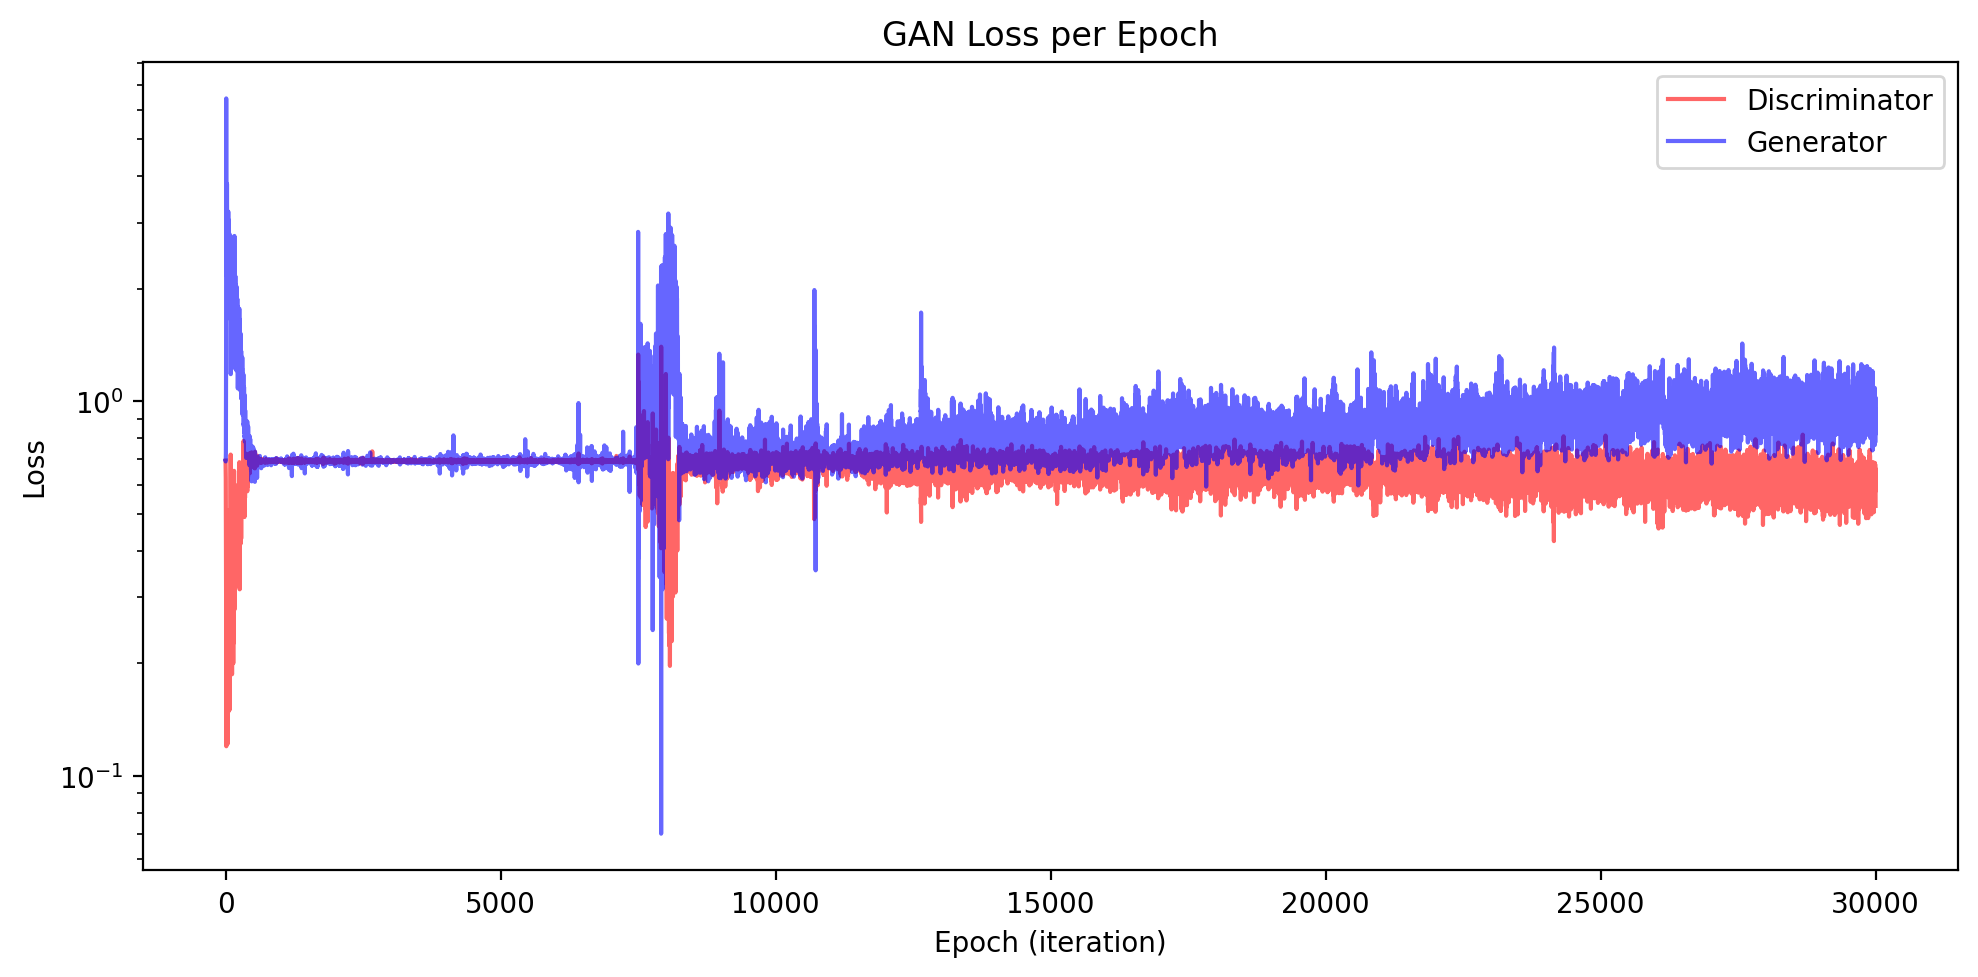

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(disc_loss, c="red", alpha=0.6, label="Discriminator")
plt.plot(gen_loss, c="blue", alpha=0.6, label="Generator")
plt.title("GAN Loss per Epoch")
plt.xlabel("Epoch (iteration)")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "GAN_Loss_per_Epoch_final.png", dpi=150)
plt.show()

## 5. Generate music

In [ ]:
noise = rng.normal(0, 1, (N_GEN_SAMPLES, LATENT_DIM)).astype(np.float32)
generated_sequences = generator.predict(noise, verbose=0)          # (N, 100, 1), tanh output in [-1, 1]


def to_tokens(sequence):
    # Undo the [-1, 1] normalisation and look the indices up in the vocabulary
    indices = np.clip(np.rint(sequence.flatten() * (n_vocab / 2) + n_vocab / 2), 0, n_vocab - 1).astype(int)
    return [pitchnames[i] for i in indices]


piece = [token for seq in generated_sequences[:AUDIO_SEQUENCES] for token in to_tokens(seq)]
midi_path = AUDIO_DIR / "gan_generated.mid"
create_midi(piece, midi_path)
save_and_play(midi_path)
print(f"Distinct tokens in the {len(piece)}-note piece: {len(set(piece))} (vocabulary: {n_vocab})")

Saved results/audio/gan_generated.mid and results/audio/gan_generated.wav


[Audio player removed to keep this notebook small enough for GitHub. The generated .wav and .mid files are in the repo's results/ folder.]


Distinct tokens in the 500-note piece: 195 (vocabulary: 627)


## 6. Novelty, diversity and FAD proxy

The functions are the original project's. As in the original, generated sequences are compared with real sequences in the model's own [-1, 1] representation. Real sequences are drawn at random here. The original used the first `n_samples` windows, which overlap and all come from the same song.

In [ ]:
real_sequences = X_train[rng.choice(len(X_train), N_GEN_SAMPLES, replace=False)]
metrics = {
    "final discriminator loss": disc_loss[-1],
    "mean discriminator loss, last 1000 iterations": float(np.mean(disc_loss[-1000:])),
    "mean discriminator accuracy, last 1000 iterations": float(np.mean(disc_acc[-1000:])),
    **generation_metrics(generated_sequences, real_sequences),
    "distinct tokens in generated piece": len(set(piece)),
}
original_gan = {"final discriminator loss": 4.0472e-06,
                "novelty (mean distance, as in original code)": 642.2842,
                "FAD proxy": 72965.6392, "diversity": 0.2751}
display(pd.DataFrame({"Original (2024)": original_gan, "This run": metrics}))

(REPO_ROOT / "results" / "gan_reproduced_metrics.json").write_text(json.dumps(
    {"metrics": metrics, "disc_loss": disc_loss[::10], "gen_loss": gen_loss[::10]}, indent=2))

,Original (2024),This run
final discriminator loss,0.000004,0.526266
"novelty (mean distance, as in original code)",642.284200,10.139100
FAD proxy,72965.639200,0.269348
diversity,0.275100,10.316468
"mean discriminator loss, last 1000 iterations",NaN,0.606411
"mean discriminator accuracy, last 1000 iterations",NaN,0.662922
"novelty (nearest neighbour, as in RESULTS.md)",NaN,7.697962
distinct tokens in generated piece,NaN,195.000000


143742

**Reading the numbers.**

- A discriminator loss near zero, with accuracy near 100%, means the discriminator has won. It no longer gives the generator useful feedback, and the original run shows exactly this.
- Few distinct tokens in the generated piece indicates mode collapse.
- In [-1, 1] space, the largest possible distance between two 100-note sequences is 20. The original novelty of 642 and FAD of 72,965 must therefore have been computed on unnormalised values, so this run's numbers are on a different scale.

In [ ]:
# On Colab, download everything this notebook produced (figures, audio, metrics) as one zip.
# Unzip it into the repo's results/ folder to keep the outputs.
if IN_COLAB:
    from google.colab import files
    archive = shutil.make_archive("/content/gan_results", "zip", REPO_ROOT / "results")
    files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>